# importing libraries

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# loading training dataset



Since data is in form of excel file we have to use pandas read_excel to load the data
After loading it is important to check the complete information of data as it can indication many of the hidden infomation such as null values in a column or a row
- Check whether any null values are there or not. if it is present then following can be done,
- Imputing data using Imputation method in sklearn

- Filling NaN values with mean, median and mode using fillna() method
- Describe data --> which can give statistical analysis

In [2]:


df = pd.read_excel('Data_Train.xlsx')
df.head()


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
## It tells pandas to show all columns when printing a dataframe.
pd.set_option('display.max_columns', None)

In [4]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [5]:
# shape of the dataset

df.shape

(10683, 11)

In [6]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

## EDA
From description we can see that Date_of_Journey is a object data type,
Therefore, we have to convert this datatype into timestamp so as to use this column properly for prediction

For this we require pandas to_datetime to convert object data type to datetime dtype.

- .dt.day method will extract only day of that date
- .dt.month method will extract only month of that date

In [11]:
df["Journey_day"] = pd.to_datetime(df.Date_of_Journey, format="%d/%m/%Y").dt.day

In [12]:
df["Journey_month"] = pd.to_datetime(df["Date_of_Journey"], format = "%d/%m/%Y").dt.month

In [13]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


In [14]:
# Now we can drop Date_of_Journey as it is of no use
df.drop(["Date_of_Journey"], axis = 1, inplace = True)

#### Departure time is when a plane leaves the gate. 
####  Similar to Date_of_Journey we can extract values from Dep_Time


In [15]:

# Extracting Hours
df["Dep_hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour

# Extracting Minutes
df["Dep_min"] = pd.to_datetime(df["Dep_Time"]).dt.minute

# Now we can drop Dep_Time as it is of no use
df.drop(["Dep_Time"], axis = 1, inplace = True)

C:\Users\Komal\AppData\Local\Temp\ipykernel_30692\431563845.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
C:\Users\Komal\AppData\Local\Temp\ipykernel_30692\431563845.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_min"] = pd.to_datetime(df["Dep_Time"]).dt.minute


In [16]:
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,16,50


#### Arrival time is when the plane pulls up to the gate.
#### Similar to Date_of_Journey we can extract values from Arrival_Time

In [17]:


# Extracting Hours
df["Arrival_hour"] = pd.to_datetime(df.Arrival_Time).dt.hour

# Extracting Minutes
df["Arrival_min"] = pd.to_datetime(df.Arrival_Time).dt.minute

# Now we can drop Arrival_Time as it is of no use
df.drop(["Arrival_Time"], axis = 1, inplace = True)

C:\Users\Komal\AppData\Local\Temp\ipykernel_30692\676665526.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_hour"] = pd.to_datetime(df.Arrival_Time).dt.hour
C:\Users\Komal\AppData\Local\Temp\ipykernel_30692\676665526.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_min"] = pd.to_datetime(df.Arrival_Time).dt.minute


The Duration column contains values like 2h 50m, 5h, or 30m, which are written in text format. Since machine learning models cannot understand text values, we first make sure every duration has both hours and minutes (for example, 5h becomes 5h 0m and 30m becomes 0h 30m). Then we extract the hours and minutes separately and convert them into numeric columns. This helps the model understand and use the duration information correctly.

In [18]:


# Assigning and converting Duration column into list
duration = list(df["Duration"])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:    # Check if duration contains only hour or mins
        if "h" in duration[i]:
            duration[i] = duration[i].strip() + " 0m"   # Adds 0 minute
        else:
            duration[i] = "0h " + duration[i]           # Adds 0 hour

duration_hours = []
duration_mins = []
for i in range(len(duration)):
    duration_hours.append(int(duration[i].split(sep = "h")[0]))    # Extract hours from duration
    duration_mins.append(int(duration[i].split(sep = "m")[0].split()[-1]))   # Extracts only minutes from duration

In [19]:
# Adding duration_hours and duration_mins list to train_data dataframe

df["Duration_hours"] = duration_hours
df["Duration_mins"] = duration_mins

In [20]:
# now drop Duration columns it has no use
df.drop(["Duration"], axis = 1, inplace = True)

# Handling Categorical Data

One can find many ways to handle categorical data. Some of them categorical data are,

- Nominal data --> data are not in any order --> OneHotEncoder is used in this case
- Ordinal data --> data are in order --> LabelEncoder is used in this case

In [21]:
df['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

C:\Users\Komal\AppData\Local\Temp\ipykernel_30692\3555116330.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


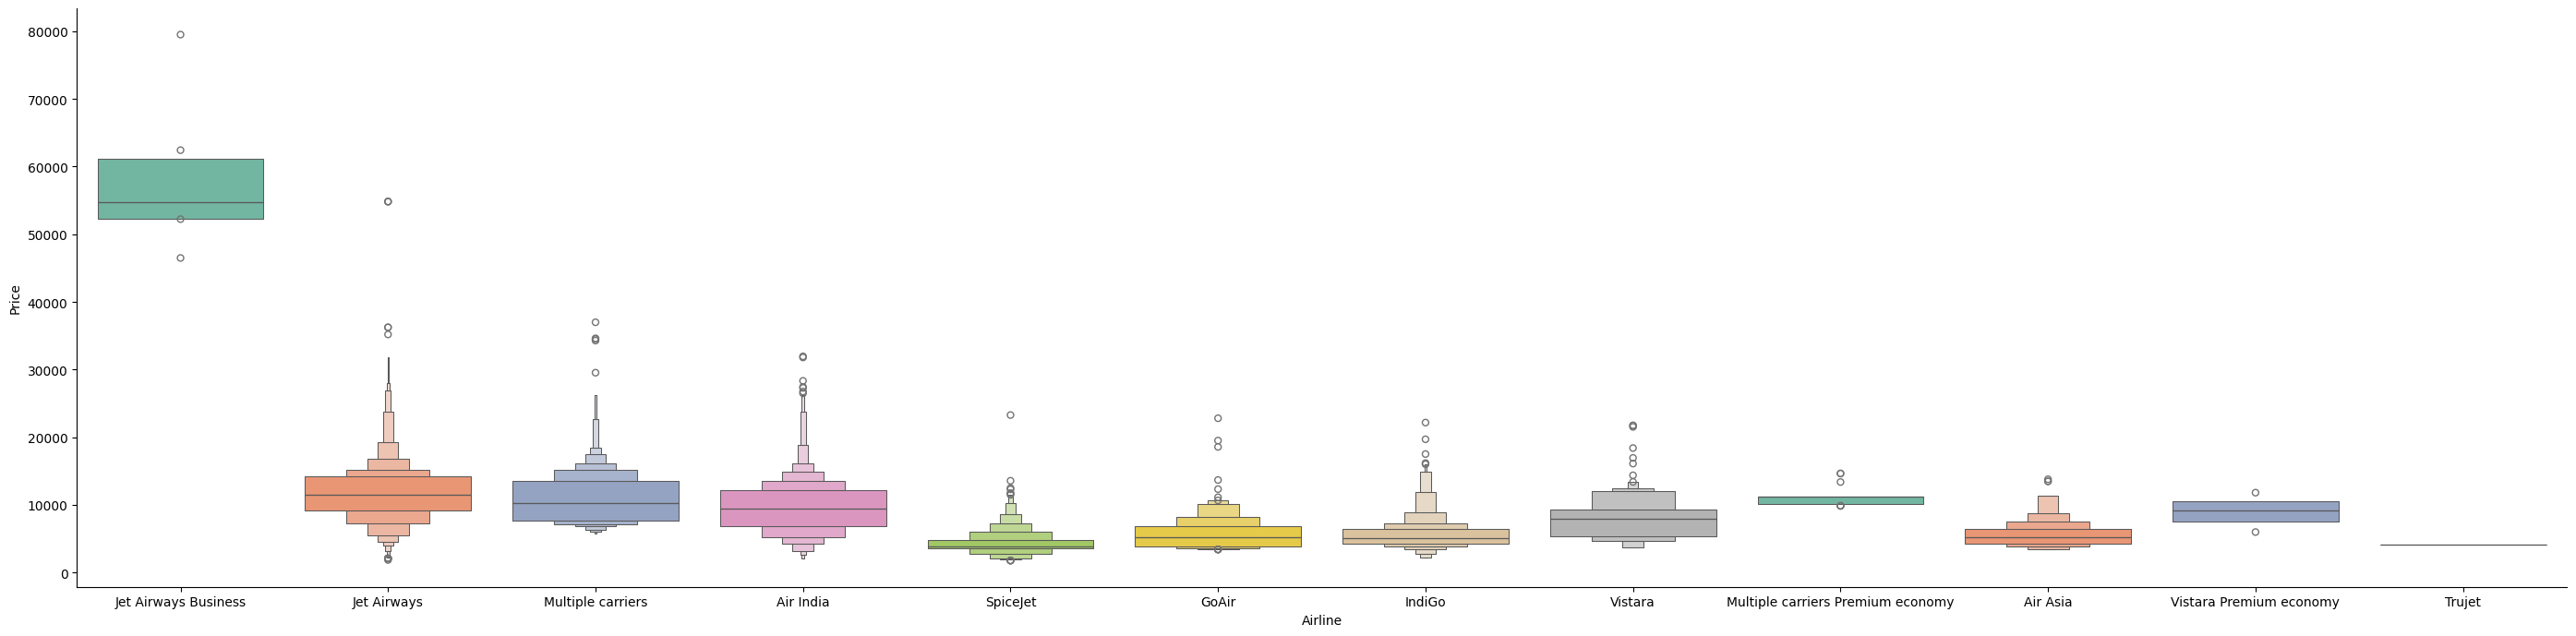

In [22]:
# From graph we can see that Jet Airways Business have the highest Price.
# Apart from the first Airline almost all are having similar median

# Airline vs Price
sns.catplot(
    y="Price",
    x="Airline",
    data=df.sort_values("Price", ascending=False),
    kind="boxen",
    height=7,
    aspect=4,
    palette="Set2"
)

plt.show()

- drop='first' → removes one category to avoid multicollinearity (dummy variable trap).

- sparse_output=False → returns normal array instead of compressed sparse matrix.

- ohe → creates the encoder object.

- fit() → learns all unique airline names.

- transform() → converts them into 0s and 1s.

- fit_transform() → does both together.

- Output → numeric matrix.

- Converts encoded array into pandas DataFrame.

- Adds proper column names like:

- Airline_IndiGo,Airline_SpiceJet,Airline_Vistara

In [23]:
# As Airline is Nominal Categorical data we will perform OneHotEncoding

ohe = OneHotEncoder(drop='first',sparse_output=False)

encoded = ohe.fit_transform(df[["Airline"]])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(["Airline"]))

encoded_df.head()

,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
df["Source"].value_counts()

Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64

C:\Users\Komal\AppData\Local\Temp\ipykernel_30692\3561095765.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(y = "Price", x = "Source", data = df.sort_values("Price", ascending = False), kind="boxen", height = 4, aspect = 3,palette="Set2"


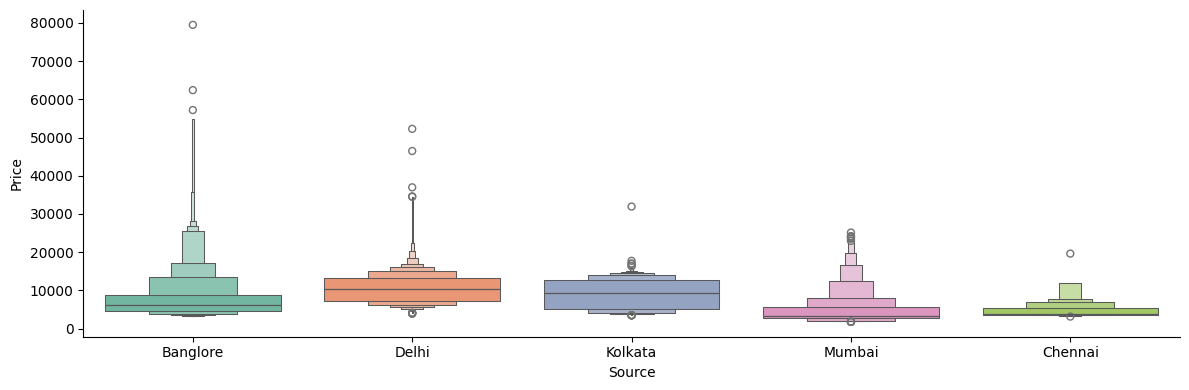

In [25]:
sns.catplot(y = "Price", x = "Source", data = df.sort_values("Price", ascending = False), kind="boxen", height = 4, aspect = 3,palette="Set2"
)
plt.show()

In [26]:
# As Source is Nominal Categorical data we will perform OneHotEncoding

ohe_source = OneHotEncoder(drop='first', sparse_output=False)

encoded_source = ohe_source.fit_transform(df[["Source"]])

source_df = pd.DataFrame(
    encoded_source,
    columns=ohe_source.get_feature_names_out(["Source"])
)

source_df.head()



,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0


In [27]:
df["Destination"].value_counts()

Destination
Cochin       4536
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [28]:
# As Destination is Nominal Categorical data we will perform OneHotEncoding

ohe_source = OneHotEncoder(drop='first', sparse_output=False)

encoded_Des = ohe_source.fit_transform(df[["Destination"]])

Des_df = pd.DataFrame(
    encoded_Des,
    columns=ohe_source.get_feature_names_out(["Destination"])
)

source_df.head()



,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0


In [29]:
df["Route"].value_counts()

Route
DEL → BOM → COK                      2376
BLR → DEL                            1552
CCU → BOM → BLR                       979
CCU → BLR                             724
BOM → HYD                             621
                                     ... 
BOM → VNS → DEL → HYD                   1
BLR → HBX → BOM → NAG → DEL             1
BLR → BOM → IXC → DEL                   1
BLR → CCU → BBI → HYD → VGA → DEL       1
BOM → BBI → HYD                         1
Name: count, Length: 128, dtype: int64

The Additional_Info column contains almost 80% no_info, which means it does not provide useful information for prediction. Since most values are the same, it will not help the model learn anything meaningful. The Route column is closely related to Total_Stops because the number of stops can already explain the route pattern. Keeping both can create redundancy. So, we drop Route and Additional_Info to remove unnecessary and duplicate information and make the dataset cleaner for the model.

In [30]:
# Additional_Info contains almost 80% no_info
# Route and Total_Stops are related to each other

df.drop(["Route", "Additional_Info"], axis = 1, inplace = True)

In [31]:
df.head()

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins
0,IndiGo,Banglore,New Delhi,non-stop,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2 stops,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2 stops,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1 stop,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1 stop,13302,1,3,16,50,21,35,4,45


In [32]:
df["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [33]:
df.replace({"non-stop": 0,"1 stop":1,"2 stops":2,"3 stops":3,"4 stops":4},inplace = True)

C:\Users\Komal\AppData\Local\Temp\ipykernel_30692\2418206445.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"non-stop": 0,"1 stop":1,"2 stops":2,"3 stops":3,"4 stops":4},inplace = True)


In [34]:
df["Airline"]

0             IndiGo
1          Air India
2        Jet Airways
3             IndiGo
4             IndiGo
            ...     
10678       Air Asia
10679      Air India
10680    Jet Airways
10681        Vistara
10682      Air India
Name: Airline, Length: 10682, dtype: object

In [35]:
# Concatenate dataframe --> df + Airline + Source + Destination
df = pd.concat([df, encoded_df, source_df, Des_df], axis=1)

In [36]:
df

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,IndiGo,Banglore,New Delhi,0.0,3897.0,24.0,3.0,22.0,20.0,1.0,10.0,2.0,50.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Air India,Kolkata,Banglore,2.0,7662.0,1.0,5.0,5.0,50.0,13.0,15.0,7.0,25.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Jet Airways,Delhi,Cochin,2.0,13882.0,9.0,6.0,9.0,25.0,4.0,25.0,19.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,IndiGo,Kolkata,Banglore,1.0,6218.0,12.0,5.0,18.0,5.0,23.0,30.0,5.0,25.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,IndiGo,Banglore,New Delhi,1.0,13302.0,1.0,3.0,16.0,50.0,21.0,35.0,4.0,45.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10679,Air India,Kolkata,Banglore,0.0,4145.0,27.0,4.0,20.0,45.0,23.0,20.0,2.0,35.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10680,Jet Airways,Banglore,Delhi,0.0,7229.0,27.0,4.0,8.0,20.0,11.0,20.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10681,Vistara,Banglore,New Delhi,0.0,12648.0,1.0,3.0,11.0,30.0,14.0,10.0,2.0,40.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
10682,Air India,Delhi,Cochin,2.0,11753.0,9.0,5.0,10.0,55.0,19.0,15.0,8.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df.drop(["Airline", "Source", "Destination"], axis = 1, inplace = True)

In [38]:
df

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0.0,3897.0,24.0,3.0,22.0,20.0,1.0,10.0,2.0,50.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2.0,7662.0,1.0,5.0,5.0,50.0,13.0,15.0,7.0,25.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,13882.0,9.0,6.0,9.0,25.0,4.0,25.0,19.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,6218.0,12.0,5.0,18.0,5.0,23.0,30.0,5.0,25.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,13302.0,1.0,3.0,16.0,50.0,21.0,35.0,4.0,45.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10679,0.0,4145.0,27.0,4.0,20.0,45.0,23.0,20.0,2.0,35.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10680,0.0,7229.0,27.0,4.0,8.0,20.0,11.0,20.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10681,0.0,12648.0,1.0,3.0,11.0,30.0,14.0,10.0,2.0,40.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
10682,2.0,11753.0,9.0,5.0,10.0,55.0,19.0,15.0,8.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
df.shape

(10683, 30)

# Test_Set

In [40]:
test_data = pd.read_excel("Test_set.xlsx")

In [41]:
test_data.shape

(2671, 10)

In [42]:
test_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


## Test Data Preprocessing  

Similar to the training data, we perform the same preprocessing steps on the test dataset to maintain consistency.

- Extract day and month from `Date_of_Journey` and drop the original column.  
- Extract hour and minute from `Dep_Time` and `Arrival_Time`, then drop them.  
- Convert `Duration` into `Duration_hours` and `Duration_mins`, then drop the original column.  
- Drop unnecessary columns like `Route` and `Additional_Info`.  
- Convert `Total_Stops` into numeric values.  
- Apply One-Hot Encoding to `Airline`, `Source`, and `Destination`.  
- Concatenate encoded columns and drop original categorical columns.  

The test data is now ready for prediction.

In [43]:
def preprocess_test_data():

    test_data["Journey_day"] = pd.to_datetime(
        test_data["Date_of_Journey"], format="%d/%m/%Y"
    ).dt.day

    test_data["Journey_month"] = pd.to_datetime(
        test_data["Date_of_Journey"], format="%d/%m/%Y"
    ).dt.month

    test_data.drop(["Date_of_Journey"], axis=1, inplace=True)

    test_data["Dep_hour"] = pd.to_datetime(test_data["Dep_Time"]).dt.hour
    test_data["Dep_min"] = pd.to_datetime(test_data["Dep_Time"]).dt.minute
    test_data.drop(["Dep_Time"], axis=1, inplace=True)

    test_data["Arrival_hour"] = pd.to_datetime(test_data["Arrival_Time"]).dt.hour
    test_data["Arrival_min"] = pd.to_datetime(test_data["Arrival_Time"]).dt.minute
    test_data.drop(["Arrival_Time"], axis=1, inplace=True)

    # Duration handling
    duration = list(test_data["Duration"])

    for i in range(len(duration)):
        if len(duration[i].split()) != 2:
            if "h" in duration[i]:
                duration[i] = duration[i] + " 0m"
            else:
                duration[i] = "0h " + duration[i]

    duration_hours = []
    duration_mins = []

    for i in range(len(duration)):
        duration_hours.append(int(duration[i].split("h")[0]))
        duration_mins.append(int(duration[i].split("m")[0].split()[-1]))

    test_data["Duration_hours"] = duration_hours
    test_data["Duration_mins"] = duration_mins
    test_data.drop(["Duration"], axis=1, inplace=True)

    test_data.drop(["Route", "Additional_Info"], axis=1, inplace=True)

    test_data.replace(
        {"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4},
        inplace=True
    )

    Airline = pd.get_dummies(test_data[["Airline"]], drop_first=True, dtype=int)
    Source = pd.get_dummies(test_data[["Source"]], drop_first=True, dtype=int)
    Destination = pd.get_dummies(test_data[["Destination"]], drop_first=True, dtype=int)

    test_data.drop(["Airline", "Source", "Destination"], axis=1, inplace=True)

    test_data = pd.concat([test_data, Airline, Source, Destination], axis=1)

    return test_data

In [44]:
test_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [45]:
test_data.shape

(2671, 10)

In [46]:
df.shape

(10683, 30)

In [47]:
df.columns

Index(['Total_Stops', 'Price', 'Journey_day', 'Journey_month', 'Dep_hour',
       'Dep_min', 'Arrival_hour', 'Arrival_min', 'Duration_hours',
       'Duration_mins', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi'],
      dtype='object')

In [48]:
X = df.loc[:, ['Total_Stops', 'Journey_day', 'Journey_month', 'Dep_hour',
       'Dep_min', 'Arrival_hour', 'Arrival_min', 'Duration_hours',
       'Duration_mins', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi']]
X.head()

,Total_Stops,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0.0,24.0,3.0,22.0,20.0,1.0,10.0,2.0,50.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2.0,1.0,5.0,5.0,50.0,13.0,15.0,7.0,25.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,9.0,6.0,9.0,25.0,4.0,25.0,19.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,12.0,5.0,18.0,5.0,23.0,30.0,5.0,25.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,3.0,16.0,50.0,21.0,35.0,4.0,45.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [49]:
y = df.iloc[:, 1]
y.head()


0     3897.0
1     7662.0
2    13882.0
3     6218.0
4    13302.0
Name: Price, dtype: float64

In [50]:


df = df.dropna()

X = df.drop("Price", axis=1)
y = df["Price"]


In [51]:
y.isnull().sum()

np.int64(0)

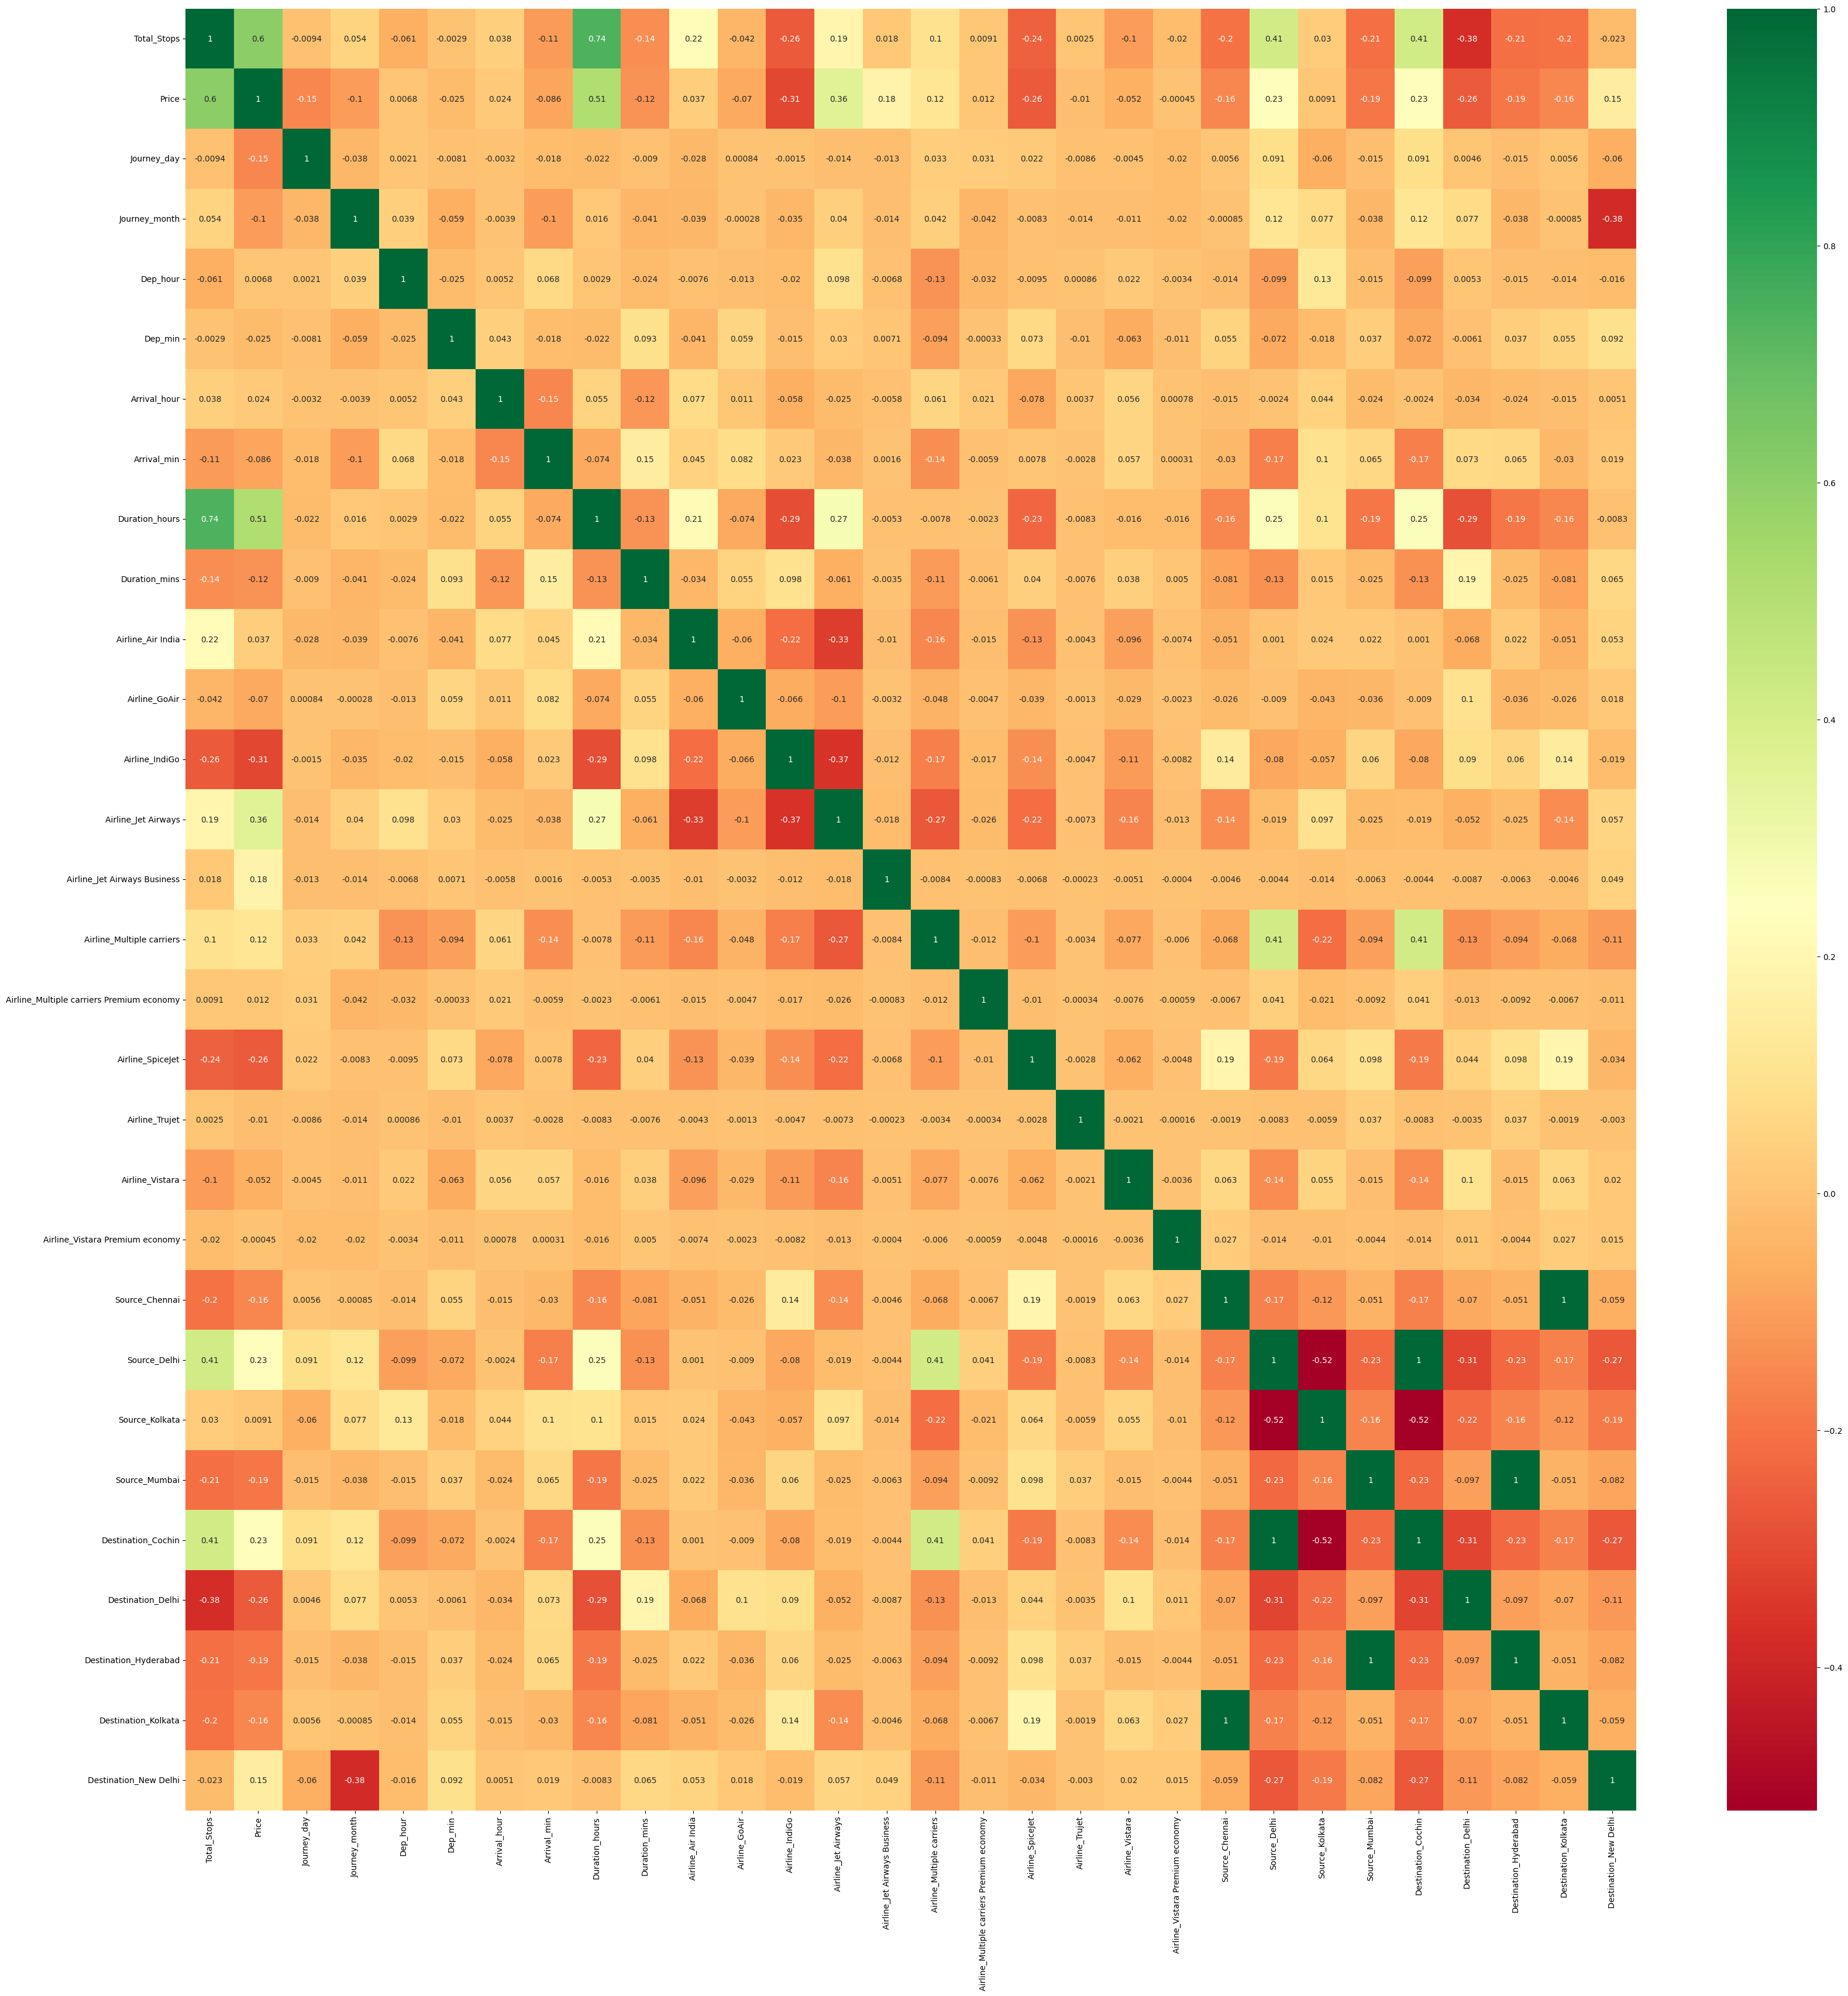

In [52]:
# Finds correlation between Independent and dependent attributes

plt.figure(figsize = (40,40))
sns.heatmap(df.corr(), annot = True, cmap = "RdYlGn")

plt.show()

Extra Trees Regressor is used for regression problems to predict continuous values like price. It is an ensemble algorithm that builds many randomized decision trees and averages their predictions. Because of this, it works well with large datasets, handles non-linear relationships, reduces overfitting, and is also commonly used to find feature importance.

However, Extra Trees Regressor does not accept null (NaN) values in the data. Even if there is only 1 NaN value in the target (y) or input features (X), the model will raise an error and stop training. So before fitting the model, we must remove or handle all missing values.

In [53]:
# Important feature using ExtraTreesRegressor

from sklearn.ensemble import ExtraTreesRegressor
selection = ExtraTreesRegressor()
selection.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [54]:
# It prints the importance score of each feature used by the Extra Trees Regressor
print(selection.feature_importances_)

[2.36471184e-01 1.41498535e-01 7.04940522e-02 2.99660584e-02
 2.70496911e-02 3.73795282e-02 2.77753585e-02 1.61053482e-01
 2.25140976e-02 8.16290166e-03 2.04482169e-03 1.16403426e-02
 9.24191597e-02 3.55480114e-02 1.56232957e-02 6.50831104e-04
 2.90962322e-03 1.20942884e-04 4.87268830e-03 9.47579812e-05
 1.22764790e-03 7.91543970e-03 5.68192939e-03 3.66401116e-03
 7.54085817e-03 1.72979302e-02 5.80339893e-03 1.07695271e-03
 2.15024685e-02]


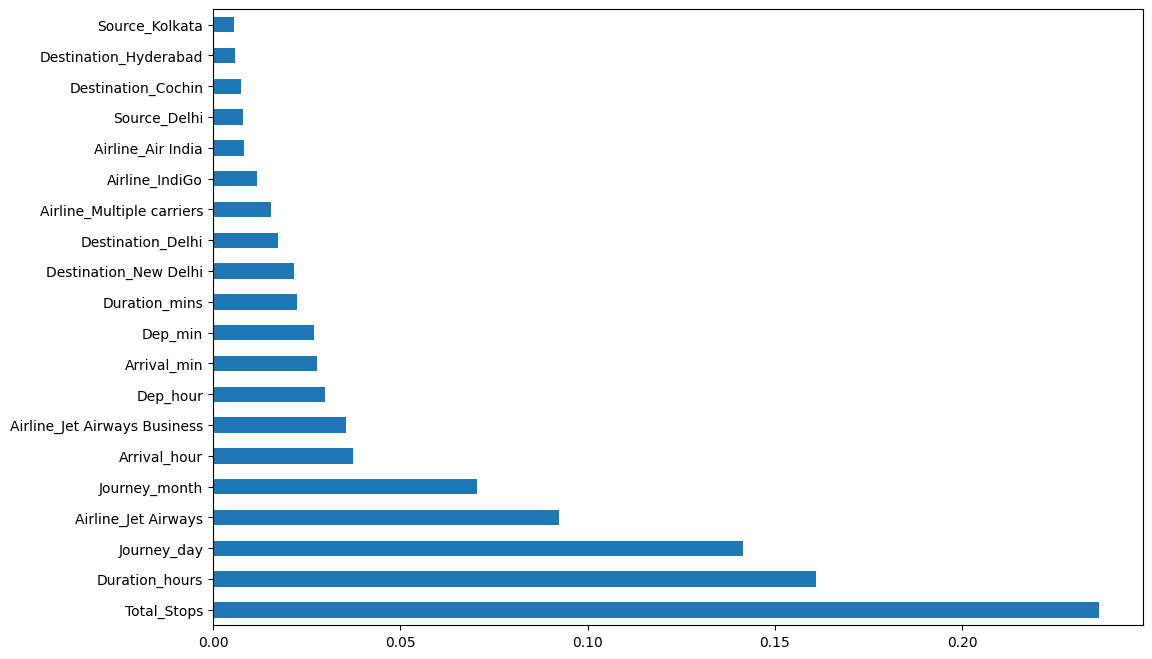

In [55]:
#plot graph of feature importances for better visualization

plt.figure(figsize = (12,8))
feat_importances = pd.Series(selection.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

# Train_Test_Split the dataset

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Scalling

ome machine learning algorithms are sensitive to the scale of input features. Models like Support Vector Regression (SVR), KNN, and Linear Regression rely on distance calculations or gradient optimization, so they perform better when features are on the same scale.

For example, if one feature ranges from 0–1 and another ranges from 0–10,000, the larger-scale feature can dominate the learning process.

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

In [ ]:
# The skewness value indicates that the target variable (Price) is not normally distributed and is highly skewed.
print(y_train.skew())

2.0143102424018315


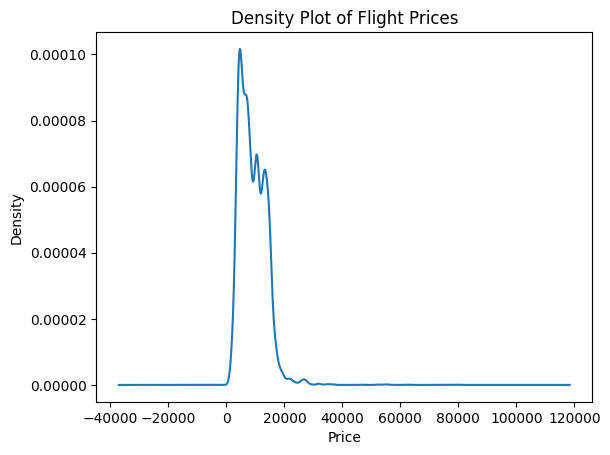

In [82]:
plt.figure()
y_train.plot(kind='density')
plt.title("Density Plot of Flight Prices")
plt.xlabel("Price")
plt.show()

High skewness can negatively impact model performance because:

- Extreme values (very high prices) dominate the learning process

- The model struggles to learn general patterns

- Prediction errors increase for normal-range values

Since many regression models perform better when the target variable is approximately normally distributed, we apply a log transformation to reduce skewness and improve model performance.

In [83]:
# Apply log transform
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

# Model Fitting

### 1. Linear Regression

In [85]:


# model creation
lr = LinearRegression()

# model fitting
lr.fit(X_train, y_train)

# model prediction
y_pred_lr = lr.predict(X_test)

# model evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R2_Score  :", r2_lr)

Linear Regression Results
MAE : 0.22551673972178415
MSE : 0.08787002609647593
RMSE: 0.2964287875636844
R2_Score  : 0.6715882975386859


### 2. Decision Tree Regressor

In [86]:

# model building
dt = DecisionTreeRegressor()

# model fitting
dt.fit(X_train, y_train)

# model prediction
y_pred_dt = dt.predict(X_test)

y_test = y_test.reset_index(drop=True) 

# model evaluation
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDecision Tree Results")
print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R2_Score  :", r2_dt)


Decision Tree Results
MAE : 0.15816859061482072
MSE : 0.06527132038650024
RMSE: 0.2554825246205702
R2_Score  : 0.7560503120086347


### 3. Gradient Boosting Regressor

In [87]:
# model building
gb = GradientBoostingRegressor()

# model fitting
gb.fit(X_train, y_train)

# model prediction
y_pred_gb = gb.predict(X_test)

y_test = y_test.reset_index(drop=True)

# model evaluation
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("\nGradient Boosting Results")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R2  :", r2_gb)


Gradient Boosting Results
MAE : 0.17225853271287234
MSE : 0.049999532244213926
RMSE: 0.22360575181379821
R2  : 0.8131281822021649


### 4. Support Vector Regressor (SVR)

In [88]:

# model building
svr = SVR(kernel='rbf')

# model fitting
svr.fit(X_train, y_train)

# model prediction
y_pred_svr = svr.predict(X_test)

y_test = y_test.reset_index(drop=True)

# model evaluation
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("\nSVR Results")
print("MAE :", mae_svr)
print("MSE :", mse_svr)
print("RMSE:", rmse_svr)
print("R2  :", r2_svr)


SVR Results
MAE : 0.16801755791740405
MSE : 0.0540271921682352
RMSE: 0.23243750163911847
R2  : 0.7980749187476763


### 5. Random Forest Regressor

In [89]:
# Model bulding
rf2 = RandomForestRegressor(random_state=42)

# model fitting
rf2.fit(X_train, y_train)

# model Prediction
y_pred_rf2 = rf2.predict(X_test)

# model Evaluation
mae_rf2 = mean_absolute_error(y_test, y_pred_rf2)
mse_rf2 = mean_squared_error(y_test, y_pred_rf2)
rmse_rf2 = np.sqrt(mse_rf2)
r2_rf2 = r2_score(y_test, y_pred_rf2)

print("\nSimple Random Forest Results")
print("MAE :", mae_rf2)
print("MSE :", mse_rf2)
print("RMSE:", rmse_rf2)
print("R2  :", r2_rf2)


Simple Random Forest Results
MAE : 0.13298960439700058
MSE : 0.0389245190058679
RMSE: 0.19729297758883335
R2  : 0.8545207265539035


# Hyperparameter Tunning on RandomForest Regressor

In [ ]:
# Define Parameter Grid


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}


# model building

rf = RandomForestRegressor(random_state=42)




grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)



# model prediction
y_test = y_test.reset_index(drop=True)

y_pred = best_rf.predict(X_test)


# model evaluation



print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))




Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
R2 Score : 0.8519669231505496
MAE      : 0.14293436591922107
MSE      : 0.0396078161296189
RMSE     : 0.19901712521694936


### 6. XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor



xgb = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=2,
    random_state=42
)




xgb.fit(X_train, y_train)


# Predict & Evaluate

prediction = xgb.predict(X_test)

y_test = y_test.reset_index(drop=True)

print("R2 Score :", r2_score(y_test, prediction))
print("MAE      :", mean_absolute_error(y_test, prediction))
print("MSE      :", mean_squared_error(y_test, prediction))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, prediction)))


# is model overfitting or underfitting?
# no there is not underfitting or overfitting if gap is > 0.15 then it's the problem.

print("Train R2:", xgb.score(X_train, y_train))
print("Test R2 :", xgb.score(X_test, y_test))

R2 Score : 0.8830900580743617
MAE      : 0.1270096101170106
MSE      : 0.03128049204992454
RMSE     : 0.17686291880980742
Train R2: 0.9333698331261353
Test R2 : 0.8830900580743617


In [93]:
import joblib

# Save model
joblib.dump(xgb, "xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!
